# Metriche per la Valutazione della Qualità delle Immagini Ricostruite

In questo notebook confrontiamo **quantitativamente** le ricostruzioni prodotte da diversi modelli di deep learning, utilizzando le metriche standard per la *Image Quality Evaluation* (IQE).

---

## 1 · Setup dell'ambiente

La prima cella prepara tutto il necessario per l'esperimento:

1. **Importazione delle librerie**: `torch`, `torchvision`, `matplotlib`, `PIL`, `tqdm`, ecc.
2. **Localizzazione delle risorse**: il codice cerca automaticamente le cartelle `Mayo/` (dataset CT), `weights/` (pesi addestrati) e il pacchetto locale `IPPy` contenente gli operatori di imaging.
3. **Selezione del device**: viene scelto il dispositivo di calcolo migliore disponibile (`cuda` > `mps` > `cpu`).
4. **Funzione di rumore**: `gaussian_noise(y, noise_level)` aggiunge rumore gaussiano con norma relativa controllata.
5. **`MayoDataset`**: dataset PyTorch custom che carica le immagini CT (scala di grigi, `256×256`).
6. **Operatore di degradazione `K`**: *motion blur* con kernel `9×9` e angolo 20°.

> **Output atteso:** nessun output diretto; la cella inizializza `train_loader`, `test_loader`, `device` e `K`.


In [29]:
import glob
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

here = Path.cwd().resolve()
for base in (here, *here.parents):
    if (base / 'weights').exists() and (base / 'Mayo').exists():
        book_root = base
        break
else:
    raise FileNotFoundError('Could not locate the course root containing Mayo and weights.')

for base in (here, *here.parents):
    if (base / 'IPPy').exists():
        ippy_root = base / 'IPPy'
        break
else:
    raise FileNotFoundError('Could not locate the local IPPy package.')

operators_spec = importlib.util.spec_from_file_location('course_ippy_operators', ippy_root / 'operators.py')
operators = importlib.util.module_from_spec(operators_spec)
operators_spec.loader.exec_module(operators)

weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)

def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    try:
        if torch.backends.mps.is_available():
            return 'mps'
    except AttributeError:
        pass
    return 'cpu'

def gaussian_noise(y, noise_level):
    e = torch.randn_like(y, device=y.device)
    return e / torch.norm(e) * torch.norm(y) * noise_level

class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()
        self.data_path = data_path
        self.data_shape = data_shape
        self.fname_list = glob.glob(f'{data_path}/*/*.png')

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        img_path = self.fname_list[idx]
        x = Image.open(img_path).convert('L')
        x = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(self.data_shape),
        ])(x)
        return x

device = get_device()
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=256)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

## 2 · Introduzione alle metriche di qualità: PSNR, SSIM e LPIPS

Prima di confrontare i modelli, è fondamentale comprendere le metriche che useremo. In questa cella le calcoliamo su un **esempio toy** (un gradiente lineare leggermente perturbato con rumore).

### Metriche utilizzate

| Metrica | Nome completo | Cosa misura | Range | Direzione "migliore" |
|---|---|---|---|---|
| **PSNR** | Peak Signal-to-Noise Ratio | Rapporto segnale/rumore basato sulla MSE: $\text{PSNR} = 10 \log_{10}\!\left(\frac{\text{MAX}^2}{\text{MSE}}\right)$ | 0 – ∞ dB | ↑ più alto = meglio |
| **SSIM** | Structural Similarity Index | Somiglianza strutturale tra due immagini, valutando luminanza, contrasto e struttura | −1 – 1 | ↑ più alto = meglio |
| **LPIPS** | Learned Perceptual Image Patch Similarity | Distanza percettiva calcolata confrontando le feature interne di una rete pre-addestrata (AlexNet) | 0 – ∞ | ↓ più basso = meglio |

### Differenze chiave tra le metriche
- **PSNR** è una metrica *pixel-wise*: misura la differenza numerica media tra i pixel, senza considerare la percezione umana. Due immagini con lo stesso PSNR possono apparire molto diverse all'occhio umano.
- **SSIM** tiene conto della *struttura locale* dell'immagine: è molto più correlato alla percezione visiva rispetto al PSNR.
- **LPIPS** è una metrica *learned*: utilizza le rappresentazioni interne di una rete neurale (AlexNet) per catturare la similarità percettiva profonda. È la metrica più vicina al giudizio umano, ma richiede una rete pre-addestrata.

### Dettagli implementativi
- **PSNR** e **SSIM** vengono calcolati con `skimage.metrics` su array NumPy.
- **LPIPS** richiede tensori PyTorch con 3 canali in range `[-1, 1]`; l'immagine grayscale viene replicata 3 volte e riscalata con la trasformazione `2x − 1`.

> **Output atteso:** tre valori stampati — PSNR (in dB), SSIM (tra 0 e 1) e LPIPS (tra 0 e 1).


In [30]:
import numpy as np
import torch
from torch import nn
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Toy example: a clean image and a slightly degraded version
x_true_np = np.linspace(0, 1, 256 * 256, dtype=np.float32).reshape(256, 256)
x_pred_np = np.clip(0.95 * x_true_np + 0.03 * np.random.randn(256, 256).astype(np.float32), 0.0, 1.0)

psnr_val = peak_signal_noise_ratio(x_true_np, x_pred_np, data_range=1.0)
ssim_val = structural_similarity(x_true_np, x_pred_np, data_range=1.0)

print(f'PSNR: {psnr_val:.3f} dB')
print(f'SSIM: {ssim_val:.4f}')

try:
    import lpips

    lpips_metric = lpips.LPIPS(net='alex')
    x_true_lp = torch.tensor(x_true_np).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    x_pred_lp = torch.tensor(x_pred_np).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)

    # LPIPS expects inputs approximately in [-1, 1]
    x_true_lp = 2 * x_true_lp - 1
    x_pred_lp = 2 * x_pred_lp - 1

    lpips_val = lpips_metric(x_true_lp, x_pred_lp).item()
    print(f'LPIPS: {lpips_val:.4f}')
except ImportError:
    print('LPIPS package not installed. To compute LPIPS offline, install the `lpips` package.')

PSNR: 27.646 dB
SSIM: 0.5370
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/.venv/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
LPIPS: 0.5911


## 3 · Componenti del Vision Transformer (ViT)

In questa cella definiamo i due sotto-moduli fondamentali del **Vision Transformer**. Queste classi saranno poi utilizzate dal modello `ViTReconstructor` definito nella cella successiva.

### `PatchEmbed` — Patch Embedding

Il primo passo del ViT è la **tokenizzazione dell'immagine**: essa viene divisa in patch non sovrapposte di dimensione $P \times P$ e ciascuna patch viene proiettata linearmente in un vettore di dimensione `embed_dim`.

Questa operazione è realizzata con una singola **convoluzione 2D** con `kernel_size = stride = patch_size`. Ogni filtro "vede" esattamente una patch e produce un singolo valore per canale di uscita.

- **Input:** `(B, C, H, W)` — batch di immagini.
- **Output:** `(B, N, d)` dove $N = (H/P) \times (W/P)$ è il numero di patch e $d$ è la dimensione dell'embedding.

### `TransformerEncoderBlock` — Blocco Encoder

Ogni blocco segue lo schema *pre-norm* del Transformer Encoder:

$$z' = z + \text{MultiHeadAttention}(\text{LayerNorm}(z))$$
$$z_{out} = z' + \text{MLP}(\text{LayerNorm}(z'))$$

| Componente | Ruolo |
|---|---|
| **LayerNorm** | Normalizzazione per stabilizzare il training |
| **MultiheadAttention** | Self-attention multi-testa: *receptive field globale* — ogni patch può interagire con tutte le altre |
| **MLP** | Due layer lineari con attivazione **GELU** in mezzo |
| **Connessioni residue** | `z + ...` per facilitare il flusso del gradiente |

> **Output atteso:** nessuno; la cella definisce le classi senza istanziarle.


In [31]:
import torch
from torch import nn

class PatchEmbed(nn.Module):
    def __init__(self, in_ch=1, embed_dim=128, patch_size=8):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(
            in_channels=in_ch,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        z = self.proj(x)  # (B, d, H/P, W/P)
        B, d, H_p, W_p = z.shape
        z = z.flatten(2).transpose(1, 2)  # (B, N, d)
        return z, (H_p, W_p)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim),
        )

    def forward(self, z):
        h = self.norm1(z)
        attn_out, _ = self.attn(h, h, h, need_weights=False)
        z = z + attn_out
        z = z + self.mlp(self.norm2(z))
        return z

## 4 · Definizione di tutte le architetture di ricostruzione

In questa cella definiamo tutte le architetture che verranno poi confrontate. L'obiettivo è avere un unico punto di definizione per poter caricare i pesi salvati.

---

### 4.1 · Reti semplici

| Modello | Struttura | Caratteristica |
|---|---|---|
| **`SimpleCNN`** | 3 layer `Conv2d` con ReLU | Mapping diretto input → output |
| **`ResCNN`** | 3 layer `Conv2d` (ReLU + Tanh) + skip | Apprende il **residuo**: `output = tanh(CNN(x)) + x` |

### 4.2 · Blocchi riutilizzabili per le UNet

- **`DoubleConv`**: due convoluzioni `3×3` consecutive con ReLU.
- **`ResidualDoubleConv`**: come `DoubleConv` con connessione residua (shortcut `1×1` se cambiano i canali).
- **`DownBlock`**: MaxPool `2×2` + blocco convoluzionale → dimezza la risoluzione spaziale.
- **`UpBlock`**: `ConvTranspose2d` (upsampling ×2) + concatenazione skip + blocco convoluzionale.
- **`AttentionGate`**: meccanismo che pesa le skip connection usando una mappa di attenzione α (sigmoid) calcolata combinando segnale dal decoder (*gate*) e dall'encoder (*skip*).
- **`AttentionUpBlock`**: `UpBlock` + `AttentionGate` applicato alla skip connection.

### 4.3 · Varianti di UNet

| Modello | Blocco base | Decoder | Note |
|---|---|---|---|
| **`SimpleUNet`** | `DoubleConv` | `UpBlock` | UNet classica (Ronneberger et al., 2015) |
| **`ResidualUNet`** | `ResidualDoubleConv` | `UpBlock` | UNet con connessioni residue interne |
| **`AttentionUNet`** | `DoubleConv` | `AttentionUpBlock` | UNet con Attention Gate nel decoder |

### 4.4 · Vision Transformer: `ViTReconstructor` ⭐

```
Immagine degradata (B,1,H,W)
       │
       ▼
  ┌─────────────┐
  │ PatchEmbed   │  → (B, N, d)   patch + proiezione lineare
  └─────────────┘
       │
       ▼  + Positional Embedding (learnable)
  ┌─────────────┐
  │ Encoder      │  × depth blocchi Transformer
  │ Transformer  │  → (B, N, d)
  └─────────────┘
       │
       ▼  reshape → (B, d, H/P, W/P)
  ┌─────────────┐
  │ Decoder CNN  │  ConvTranspose2d + Conv2d → (B, 1, H, W)
  └─────────────┘
       │
       ▼  + residual (input originale)
    Output ricostruito
```

- **Positional Embedding**: parametro learnable `(1, N, d)` per conservare l'informazione spaziale.
- **Connessione residua globale**: `output = input + decoder(encoder(input))` — la rete apprende solo la *correzione*.

### 4.5 · `UNetPP` (UNet++)

UNet++ (Zhou et al., 2018) introduce **connessioni dense** tra i livelli dell'encoder e del decoder. Ogni nodo del decoder riceve le feature da *tutti* i nodi precedenti dello stesso livello, oltre che dal livello inferiore, favorendo un riuso più ricco delle feature multi-scala.

> **Output atteso:** nessuno; la cella definisce le classi senza istanziarle.


In [32]:
import math
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

class SimpleCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding='same')
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding='same')
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding='same')
        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        return self.conv3(h)


class ResCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding='same')
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding='same')
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding='same')
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        return self.tanh(self.conv3(h)) + x


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class ResidualDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        h = self.relu(self.conv1(x))
        h = self.conv2(h)
        return self.relu(h + identity)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, block_cls=DoubleConv):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block = block_cls(in_ch, out_ch)

    def forward(self, x):
        return self.block(self.pool(x))


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, block_cls=DoubleConv):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.block = block_cls(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = torch.nn.functional.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.gate_proj = nn.Conv2d(gate_ch, inter_ch, kernel_size=1)
        self.skip_proj = nn.Conv2d(skip_ch, inter_ch, kernel_size=1)
        self.psi = nn.Conv2d(inter_ch, 1, kernel_size=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, gate, skip):
        a = self.gate_proj(gate)
        b = self.skip_proj(skip)
        if a.shape[-2:] != b.shape[-2:]:
            a = torch.nn.functional.interpolate(a, size=b.shape[-2:], mode='bilinear', align_corners=False)
        alpha = self.sigmoid(self.psi(self.relu(a + b)))
        return skip * alpha


class AttentionUpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.attn = AttentionGate(out_ch, skip_ch, out_ch)
        self.block = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        skip = self.attn(x, skip)
        if x.shape[-2:] != skip.shape[-2:]:
            x = torch.nn.functional.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch)
        self.dec3 = UpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch)
        self.dec2 = UpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch)
        self.dec1 = UpBlock(2 * base_ch, base_ch, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)


class ResidualUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = ResidualDoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch, block_cls=ResidualDoubleConv)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch, block_cls=ResidualDoubleConv)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch, block_cls=ResidualDoubleConv)
        self.dec3 = UpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch, block_cls=ResidualDoubleConv)
        self.dec2 = UpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch, block_cls=ResidualDoubleConv)
        self.dec1 = UpBlock(2 * base_ch, base_ch, base_ch, block_cls=ResidualDoubleConv)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)


class AttentionUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch)
        self.dec3 = AttentionUpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch)
        self.dec2 = AttentionUpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch)
        self.dec1 = AttentionUpBlock(2 * base_ch, base_ch, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)

class ViTReconstructor(nn.Module):
    def __init__(
        self,
        img_size=256,
        patch_size=8,
        in_ch=1,
        out_ch=1,
        embed_dim=128,
        depth=4,
        num_heads=4,
        mlp_dim=256,
    ):
        super().__init__()

        assert img_size % patch_size == 0, 'img_size must be divisible by patch_size.'
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2

        self.patch_embed = PatchEmbed(in_ch=in_ch, embed_dim=embed_dim, patch_size=patch_size)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

        self.encoder = nn.Sequential(*[
            TransformerEncoderBlock(embed_dim=embed_dim, num_heads=num_heads, mlp_dim=mlp_dim)
            for _ in range(depth)
        ])

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=embed_dim,
                out_channels=embed_dim // 2,
                kernel_size=patch_size,
                stride=patch_size,
            ),
            nn.ReLU(),
            nn.Conv2d(embed_dim // 2, embed_dim // 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(embed_dim // 2, embed_dim // 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(embed_dim // 4, out_ch, kernel_size=1),
        )

    def forward(self, x):
        residual = x
        z, (H_p, W_p) = self.patch_embed(x)
        z = z + self.pos_embed[:, :z.shape[1], :]
        z = self.encoder(z)

        feat = z.transpose(1, 2).reshape(x.shape[0], -1, H_p, W_p)
        out = self.decoder(feat)
        return residual + out


class UNetPP(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.x0_0 = DoubleConv(in_ch, base_ch)
        self.x1_0 = DoubleConv(base_ch, 2 * base_ch)
        self.x2_0 = DoubleConv(2 * base_ch, 4 * base_ch)
        self.x0_1 = DoubleConv(base_ch + 2 * base_ch, base_ch)
        self.x1_1 = DoubleConv(2 * base_ch + 4 * base_ch, 2 * base_ch)
        self.x0_2 = DoubleConv(base_ch * 2 + 2 * base_ch, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        x0_0 = self.x0_0(x)
        x1_0 = self.x1_0(self.pool(x0_0))
        x2_0 = self.x2_0(self.pool(x1_0))
        x0_1 = self.x0_1(torch.cat([x0_0, self.up(x1_0)], dim=1))
        x1_1 = self.x1_1(torch.cat([x1_0, self.up(x2_0)], dim=1))
        x0_2 = self.x0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], dim=1))
        return self.out_conv(x0_2)


## 5 · Caricamento dei modelli e confronto quantitativo

Questa è la cella principale dell'analisi comparativa. Le operazioni sono:

1. **Caricamento dei pesi**: la funzione `try_load_model` carica i pesi `.pth` per ciascun modello. Se un file non esiste, il modello viene saltato.
2. **Preparazione della metrica LPIPS**: viene istanziata la rete AlexNet di LPIPS (se il pacchetto è installato).
3. **Loop di valutazione**: per `num_eval` immagini dal test set:
   - Si applica la degradazione `y = K(x) + noise`.
   - Ogni modello ricostruisce l'immagine: `x̂ = model(y)`.
   - Si calcolano **MSE**, **PSNR**, **SSIM** (e **LPIPS** se disponibile) tra `x̂` e il ground truth `x`.
4. **Tabella riassuntiva**: i risultati medi vengono stampati in formato tabellare.
5. **Confronto visivo**: per una immagine di esempio, viene generata una figura con:
   - Prima colonna: immagine degradata.
   - Colonne successive: ricostruzione di ciascun modello con le metriche sovrapposte.

### Modelli confrontati

| # | Modello | Tipo di architettura |
|---|---|---|
| 1 | CNN | CNN a 3 layer |
| 2 | ResCNN | CNN residuale |
| 3 | UNet | UNet classica |
| 4 | Residual UNet | UNet con blocchi residui |
| 5 | Attention UNet | UNet con Attention Gate |
| 6 | UNet++ | UNet con connessioni dense |
| 7 | **ViT** | Vision Transformer |

### Interpretazione dei risultati
- Un **PSNR alto** e un **SSIM alto** indicano una buona ricostruzione pixel-wise e strutturale.
- Un **LPIPS basso** indica che l'immagine ricostruita è percepita come simile all'originale.
- Il confronto tra le metriche permette di capire quale modello produce le ricostruzioni migliori, e se le metriche concordano tra loro.

> **Output atteso:** tabella di metriche medie per ogni modello + figura comparativa con immagini e metriche.


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/.venv/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


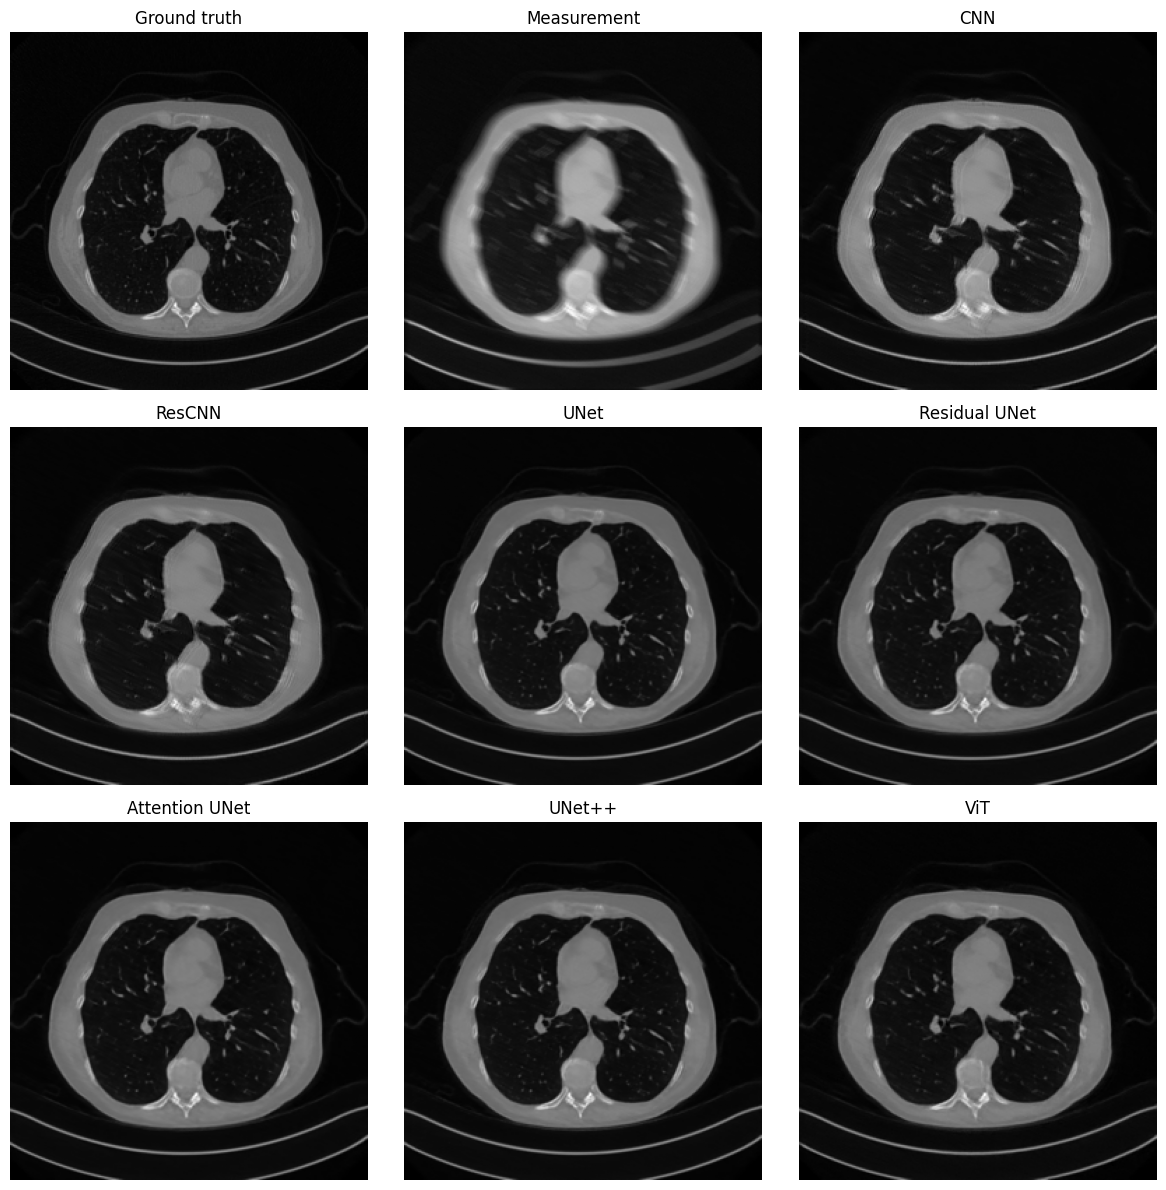

Average metrics over 8 test images
             CNN | MSE: 0.000337 | PSNR: 34.736 dB | SSIM: 0.9287 | LPIPS: 0.0648
          ResCNN | MSE: 0.000312 | PSNR: 35.059 dB | SSIM: 0.9304 | LPIPS: 0.0614
            UNet | MSE: 0.000088 | PSNR: 40.582 dB | SSIM: 0.9696 | LPIPS: 0.0172
   Residual UNet | MSE: 0.000114 | PSNR: 39.472 dB | SSIM: 0.9510 | LPIPS: 0.0249
  Attention UNet | MSE: 0.000092 | PSNR: 40.489 dB | SSIM: 0.9707 | LPIPS: 0.0245
          UNet++ | MSE: 0.000070 | PSNR: 41.649 dB | SSIM: 0.9750 | LPIPS: 0.0190
             ViT | MSE: 0.000152 | PSNR: 38.409 dB | SSIM: 0.9574 | LPIPS: 0.0297


In [33]:

def try_load_model(name, model, filename):
    path = weights_dir / filename
    if not path.exists():
        print(f'Skipping {name}: {path.name} not found.')
        return None
    model.load_state_dict(torch.load(path, map_location='cpu', weights_only=True))
    model = model.to(device)
    model.eval()
    return model


models = {
    'CNN': try_load_model('CNN', SimpleCNN(in_ch=1, out_ch=1, n_filters=32), 'CNN.pth'),
    'ResCNN': try_load_model('ResCNN', ResCNN(in_ch=1, out_ch=1, n_filters=32), 'ResCNN.pth'),
    'UNet': try_load_model('UNet', SimpleUNet(in_ch=1, out_ch=1, base_ch=32), 'UNet.pth'),
    'Residual UNet': try_load_model('Residual UNet', ResidualUNet(in_ch=1, out_ch=1, base_ch=32), 'ResidualUNet.pth'),
    'Attention UNet': try_load_model('Attention UNet', AttentionUNet(in_ch=1, out_ch=1, base_ch=32), 'AttentionUNet.pth'),
    'UNet++': try_load_model('UNet++', UNetPP(in_ch=1, out_ch=1, base_ch=32), 'UNetPP.pth'),
    'ViT': try_load_model('ViT', ViTReconstructor(img_size=256, patch_size=8, in_ch=1, out_ch=1, embed_dim=128, depth=4, num_heads=4, mlp_dim=256), 'ViT.pth'),
}
models = {name: model for name, model in models.items() if model is not None}

lpips_metric = None
try:
    import lpips
    lpips_metric = lpips.LPIPS(net='alex').to(device)
    lpips_metric.eval()
except ImportError:
    print('LPIPS package not installed. The comparison will report MSE, PSNR, and SSIM only.')

results = {name: {'MSE': [], 'PSNR': [], 'SSIM': [], 'LPIPS': []} for name in models}
noise_level = 0.01
num_eval = 8
visual_data = None

torch.manual_seed(123)
for idx in range(num_eval):
    x_true = test_dataset[idx].unsqueeze(0).to(device)
    with torch.no_grad():
        y_delta = K(x_true)
        y_delta = y_delta + gaussian_noise(y_delta, noise_level=noise_level)
        reconstructions = {name: model(y_delta).clamp(0.0, 1.0) for name, model in models.items()}

    x_true_np = x_true.squeeze().cpu().numpy()
    y_delta_np = y_delta.squeeze().cpu().numpy()

    if visual_data is None:
        visual_data = {
            'x_true': x_true_np,
            'y_delta': y_delta_np,
            'recons': {name: rec.squeeze().cpu().numpy() for name, rec in reconstructions.items()},
        }

    for name, rec in reconstructions.items():
        rec_np = rec.squeeze().cpu().numpy()
        mse_val = float(np.mean((rec_np - x_true_np) ** 2))
        psnr_val = peak_signal_noise_ratio(x_true_np, rec_np, data_range=1.0)
        ssim_val = structural_similarity(x_true_np, rec_np, data_range=1.0)

        results[name]['MSE'].append(mse_val)
        results[name]['PSNR'].append(psnr_val)
        results[name]['SSIM'].append(ssim_val)

        if lpips_metric is not None:
            with torch.no_grad():
                x_true_lp = 2 * x_true.repeat(1, 3, 1, 1) - 1
                rec_lp = 2 * rec.repeat(1, 3, 1, 1) - 1
                lpips_val = lpips_metric(x_true_lp, rec_lp).item()
            results[name]['LPIPS'].append(lpips_val)

images = [visual_data['x_true'], visual_data['y_delta']] + [visual_data['recons'][name] for name in models]
titles = ['Ground truth', 'Measurement'] + list(models.keys())
ncols = 3
nrows = math.ceil(len(images) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).reshape(nrows, ncols)
for ax, image, title in zip(axes.flat, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
for ax in axes.flat[len(images):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Average metrics over {num_eval} test images')
for name in models:
    mse_mean = np.mean(results[name]['MSE'])
    psnr_mean = np.mean(results[name]['PSNR'])
    ssim_mean = np.mean(results[name]['SSIM'])
    line = f"{name:>16} | MSE: {mse_mean:.6f} | PSNR: {psnr_mean:.3f} dB | SSIM: {ssim_mean:.4f}"
    if results[name]['LPIPS']:
        line += f" | LPIPS: {np.mean(results[name]['LPIPS']):.4f}"
    print(line)

## 6 · Studio sull'effetto della funzione di loss

Oltre a confrontare le architetture, è fondamentale capire come la **scelta della funzione di loss** influenzi la qualità della ricostruzione. In questa cella:

1. **`LossStudyCNN`**: una piccola CNN a 3 layer usata come modello di studio. Essendo leggera, permette di addestrare rapidamente più varianti.

2. **Funzioni di loss definite**:

| Loss | Formula | Proprietà |
|---|---|---|
| **MSE** (Mean Squared Error) | $\frac{1}{N}\sum(x - \hat{x})^2$ | Penalizza di più gli errori grandi; può produrre ricostruzioni sfocate |
| **L1** (Mean Absolute Error) | $\frac{1}{N}\sum|x - \hat{x}|$ | Più robusta agli outlier rispetto a MSE; preserva meglio i bordi |
| **SSIM Loss** | $1 - \text{SSIM}(x, \hat{x})$ | Ottimizza direttamente la qualità strutturale percepita |
| **Fourier Loss** | $\text{mean}(|\mathcal{F}(x) - \mathcal{F}(\hat{x})|)$ | Penalizza le differenze nel dominio delle frequenze; aiuta a preservare texture e dettagli fini |

3. **`run_loss_experiment`**: funzione di training che, per ogni configurazione di loss, addestra una `LossStudyCNN` da zero e restituisce lo storico delle loss, la ricostruzione finale e le metriche.

> **Output atteso:** nessun output diretto; la cella prepara le funzioni e le configurazioni per gli esperimenti della cella successiva.


In [34]:
from torch.utils.data import DataLoader, Subset

class LossStudyCNN(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, n_filters=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, n_filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(n_filters, n_filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(n_filters, out_ch, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


class SSIMLoss(nn.Module):
    def __init__(self, c1=0.01 ** 2, c2=0.03 ** 2):
        super().__init__()
        self.c1 = c1
        self.c2 = c2

    def forward(self, x, y):
        mu_x = torch.nn.functional.avg_pool2d(x, kernel_size=3, stride=1, padding=1)
        mu_y = torch.nn.functional.avg_pool2d(y, kernel_size=3, stride=1, padding=1)
        sigma_x = torch.nn.functional.avg_pool2d(x * x, kernel_size=3, stride=1, padding=1) - mu_x ** 2
        sigma_y = torch.nn.functional.avg_pool2d(y * y, kernel_size=3, stride=1, padding=1) - mu_y ** 2
        sigma_xy = torch.nn.functional.avg_pool2d(x * y, kernel_size=3, stride=1, padding=1) - mu_x * mu_y
        ssim_map = ((2 * mu_x * mu_y + self.c1) * (2 * sigma_xy + self.c2)) / ((mu_x ** 2 + mu_y ** 2 + self.c1) * (sigma_x + sigma_y + self.c2) + 1e-8)
        return 1.0 - ssim_map.mean()


class FourierLoss(nn.Module):
    def forward(self, x, y):
        fx = torch.fft.fft2(x, norm='ortho')
        fy = torch.fft.fft2(y, norm='ortho')
        return torch.mean(torch.abs(fx - fy))


mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()
ssim_loss = SSIMLoss()
fourier_loss = FourierLoss()

loss_study_loader = DataLoader(Subset(train_dataset, list(range(min(32, len(train_dataset))))), batch_size=4, shuffle=True)

with torch.no_grad():
    x_fixed = test_dataset[0].unsqueeze(0).to(device)
    y_fixed = K(x_fixed)
    y_fixed = y_fixed + gaussian_noise(y_fixed, noise_level=0.01)


def run_loss_experiment(configs, num_epochs=4, max_batches=8):
    histories = {}
    reconstructions = {}
    metrics = {}

    for name, loss_fn in configs.items():
        torch.manual_seed(0)
        model = LossStudyCNN().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        history = []

        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0.0
            for step, x_batch in enumerate(loss_study_loader, start=1):
                if step > max_batches:
                    break
                x_batch = x_batch.to(device)
                with torch.no_grad():
                    y_batch = K(x_batch)
                    y_batch = y_batch + gaussian_noise(y_batch, noise_level=0.01)

                prediction = model(y_batch)
                loss = loss_fn(prediction, x_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            history.append(epoch_loss / min(len(loss_study_loader), max_batches))

        model.eval()
        with torch.no_grad():
            rec = model(y_fixed).clamp(0.0, 1.0)
        rec_np = rec.squeeze().cpu().numpy()
        x_fixed_np = x_fixed.squeeze().cpu().numpy()

        histories[name] = history
        reconstructions[name] = rec_np
        metrics[name] = {
            'MSE': float(np.mean((rec_np - x_fixed_np) ** 2)),
            'PSNR': peak_signal_noise_ratio(x_fixed_np, rec_np, data_range=1.0),
            'SSIM': structural_similarity(x_fixed_np, rec_np, data_range=1.0),
        }

    return histories, reconstructions, metrics


## 7 · Esecuzione degli esperimenti e visualizzazione dei risultati

In quest'ultima cella eseguiamo due esperimenti:

### Esperimento 1 — Loss pure
Confrontiamo l'addestramento con una singola funzione di loss:
- **MSE**: baseline standard.
- **L1**: confronto con una metrica più robusta.
- **SSIM**: training guidato dalla similarità strutturale.

### Esperimento 2 — Loss miste (combinate)
Testiamo combinazioni di più loss per sfruttare i punti di forza di ciascuna:
- **MSE + 0.1 Fourier**: aggiunge un termine che penalizza le differenze nelle frequenze.
- **0.5 MSE + 0.5 L1**: bilanciamento tra precisione pixel-wise e robustezza ai bordi.
- **MSE + 0.2 SSIM + 0.1 Fourier**: combinazione di dominio spaziale, strutturale e frequenziale.

### Visualizzazione
Per ogni esperimento, `show_loss_experiment` genera una figura con:
- **Riga superiore**: ground truth, immagine degradata e le ricostruzioni di ciascuna loss.
- **Riga inferiore**: andamento della loss durante il training (convergenza).
- **Tabella delle metriche**: MSE, PSNR e SSIM per ogni configurazione.

### Cosa osservare
- La loss **MSE** tende a produrre immagini sfocate (media degli errori).
- La loss **L1** preserva meglio i bordi.
- La loss **SSIM** migliora la qualità percepita ma può essere instabile.
- Le **combinazioni** spesso danno i risultati migliori, bilanciando aspetti diversi della qualità.

> **Output atteso:** due figure comparative (una per esperimento) + tabelle con metriche MSE/PSNR/SSIM per ogni configurazione di loss.


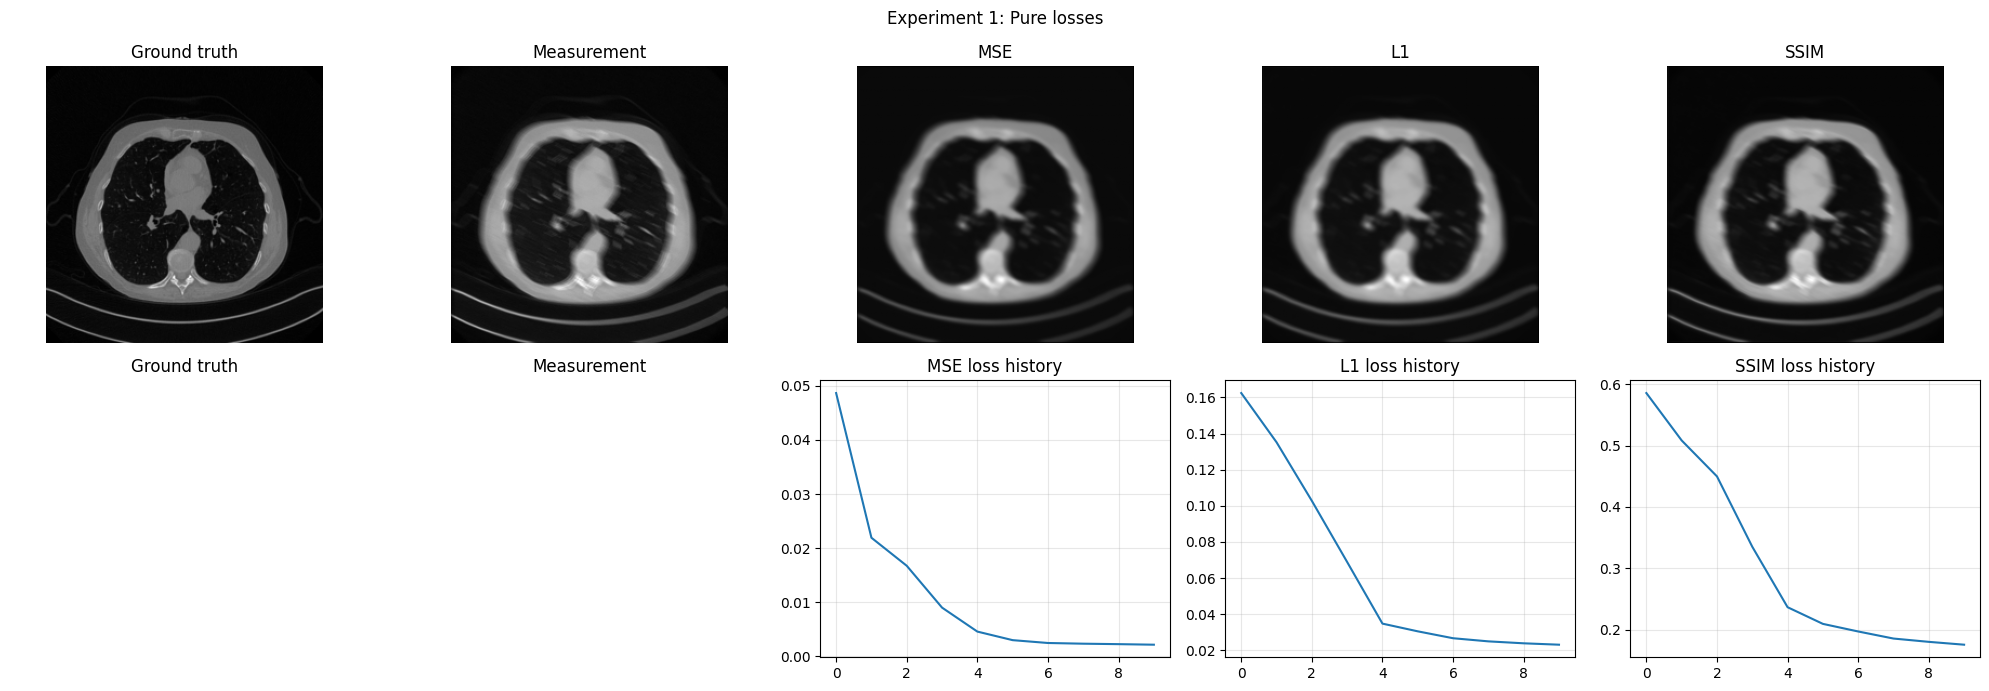

Experiment 1: Pure losses
                         MSE | MSE: 0.002414 | PSNR: 26.172 dB | SSIM: 0.7486
                          L1 | MSE: 0.002230 | PSNR: 26.517 dB | SSIM: 0.7730
                        SSIM | MSE: 0.002080 | PSNR: 26.819 dB | SSIM: 0.7965


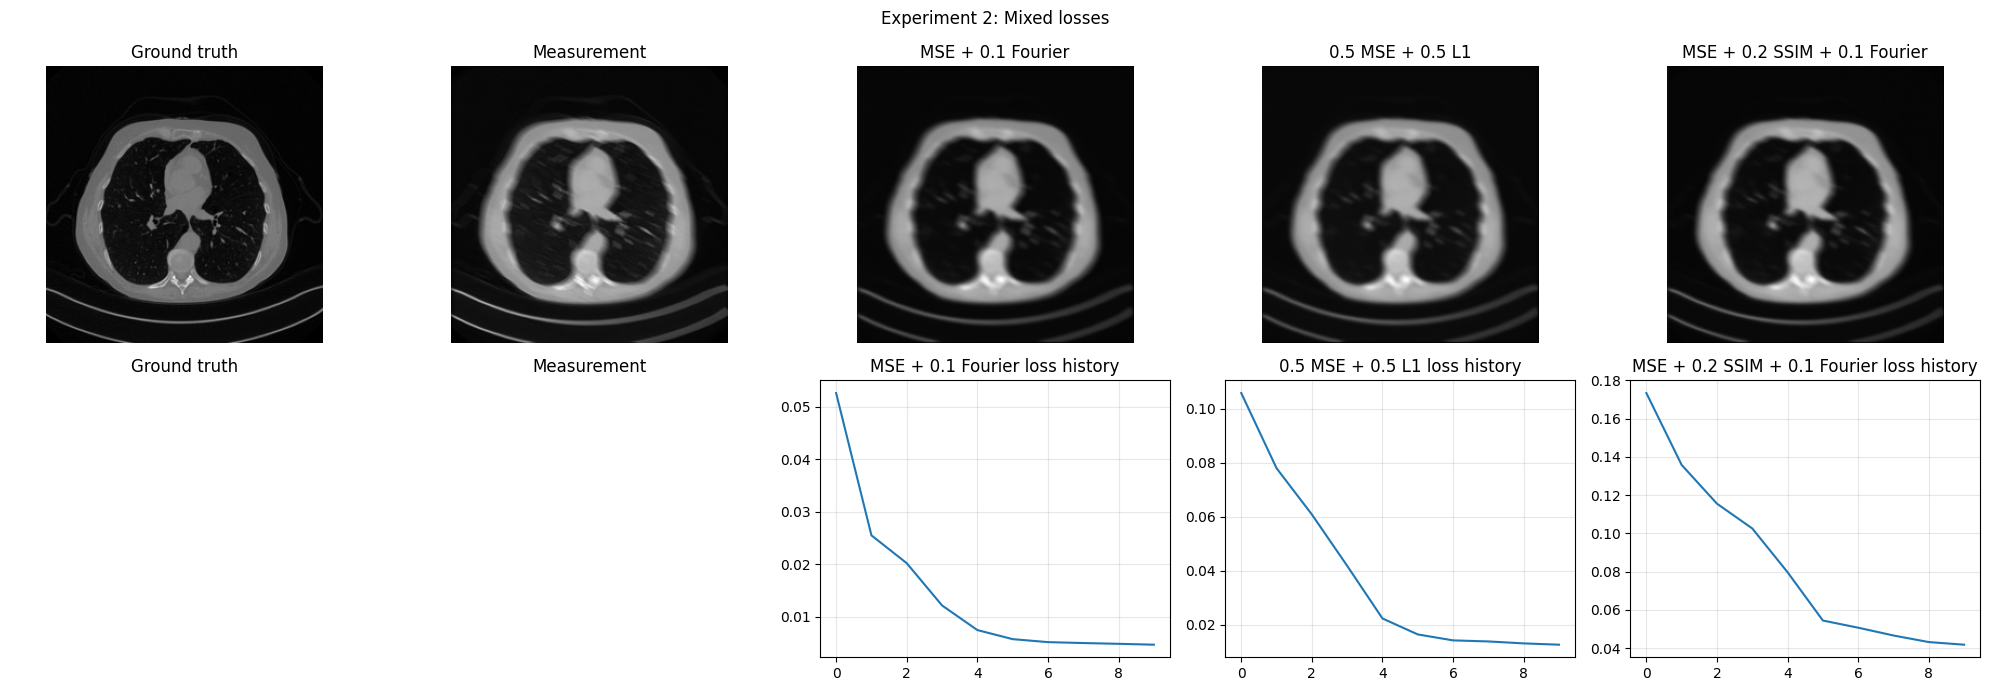

Experiment 2: Mixed losses
           MSE + 0.1 Fourier | MSE: 0.002295 | PSNR: 26.393 dB | SSIM: 0.7703
            0.5 MSE + 0.5 L1 | MSE: 0.002248 | PSNR: 26.482 dB | SSIM: 0.7721
MSE + 0.2 SSIM + 0.1 Fourier | MSE: 0.002215 | PSNR: 26.546 dB | SSIM: 0.7796


In [35]:


def show_loss_experiment(title, histories, reconstructions, metrics):
    images = [x_fixed.squeeze().cpu().numpy(), y_fixed.squeeze().cpu().numpy()] + [reconstructions[name] for name in histories]
    titles = ['Ground truth', 'Measurement'] + list(histories.keys())
    fig, axes = plt.subplots(2, len(histories) + 2, figsize=(4 * (len(histories) + 2), 7))
    for ax, image, name in zip(axes[0], images, titles):
        ax.imshow(image, cmap='gray')
        ax.set_title(name)
        ax.axis('off')
    for ax, name in zip(axes[1, :2], ['Ground truth', 'Measurement']):
        ax.axis('off')
        ax.set_title(name)
    for ax, name in zip(axes[1, 2:], histories):
        ax.plot(histories[name])
        ax.set_title(f'{name} loss history')
        ax.grid(alpha=0.3)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    print(title)
    for name, vals in metrics.items():
        print(f"{name:>28} | MSE: {vals['MSE']:.6f} | PSNR: {vals['PSNR']:.3f} dB | SSIM: {vals['SSIM']:.4f}")


pure_loss_configs = {
    'MSE': lambda pred, target: mse_loss(pred, target),
    'L1': lambda pred, target: l1_loss(pred, target),
    'SSIM': lambda pred, target: ssim_loss(pred, target),
}

mixed_loss_configs = {
    'MSE + 0.1 Fourier': lambda pred, target: mse_loss(pred, target) + 0.1 * fourier_loss(pred, target),
    '0.5 MSE + 0.5 L1': lambda pred, target: 0.5 * mse_loss(pred, target) + 0.5 * l1_loss(pred, target),
    'MSE + 0.2 SSIM + 0.1 Fourier': lambda pred, target: mse_loss(pred, target) + 0.2 * ssim_loss(pred, target) + 0.1 * fourier_loss(pred, target),
}

pure_histories, pure_recons, pure_metrics = run_loss_experiment(pure_loss_configs, num_epochs=10)
show_loss_experiment('Experiment 1: Pure losses', pure_histories, pure_recons, pure_metrics)

mixed_histories, mixed_recons, mixed_metrics = run_loss_experiment(mixed_loss_configs, num_epochs=10)
show_loss_experiment('Experiment 2: Mixed losses', mixed_histories, mixed_recons, mixed_metrics)